 ## Lab - Week 10 - Dropout

### Ways to reduce overfitting in neural networks
 - Getting more training data
 - Reducing the capacity of the network (last week's lab)
 - Adding weight regularization (last week's lab)
 - Adding dropout (the subject for this week)
 - Using transfer learning

### Typical training and validation loss over time
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*0VWDpLIRcMTssDf-zyOR4w.jpeg)

## Dropout Regularization

**Dropout** is a regularization technique that involves randomly "dropping out" (setting to zero) a subset of a layer's output features during training.

For example, if a layer would normally return the vector `[0.2, 0.5, 1.3, 0.8, 1.1]` for a specific input, applying dropout might result in `[0, 0.5, 1.3, 0, 1.1]`. The **dropout rate** defines the fraction of features zeroed out and typically ranges between 0.2 and 0.5.

At test time, no units are dropped. To compensate for the fact that all neurons are now active (unlike during training), the layer's output values are scaled down by a factor equal to the dropout rate. This ensures that the expected sum of the inputs to the next layer remains consistent between training and inference.


![dropout](https://cdn-images-1.medium.com/max/1600/1*iWQzxhVlvadk6VAJjsgXgg.png)

In Keras you can introduce dropout in a network via the `Dropout` layer, which gets applied to the output of layer right before it, e.g.:
```python
model.add(layers.Dropout(0.5))
```

### Part 1: Load and Prepare Data - IMDB dataset

In [1]:
from keras import models
from keras import layers
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      for j in sequence:
        results[i, j] += 1
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**As a routine, perform a sanity check on the dataset to understand the shape of the train and test inputs and outputs, and print out a sample of the data.**

In [2]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nSample x_train[0] (first 20 values):", x_train[0][:20])
print("Sample y_train[0]:", y_train[0])

print("\nLabel distribution (train):", np.unique(y_train, return_counts=True))
print("Label distribution (test):", np.unique(y_test, return_counts=True))

x_train shape: (25000, 10000)
x_test shape: (25000, 10000)
y_train shape: (25000,)
y_test shape: (25000,)

Sample x_train[0] (first 20 values): [ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.  0.  0.  6.  3.  3.  4. 11.  3.
  3.  2.]
Sample y_train[0]: 1.0

Label distribution (train): (array([0., 1.], dtype=float32), array([12500, 12500]))
Label distribution (test): (array([0., 1.], dtype=float32), array([12500, 12500]))


### Part 2: Build a Simple Neural Network Model
Objective: Create a basic neural network model using Keras.

**Questions**
- What type of classification problem are we solving?
- How many neurons should there be in the output layer?
- What should be the activation function of the output layer?
- What loss function should be used?
- What activation function should be used on the hidden layers?


Build a sequential model with one dense layer with 8 units and train it for 20 epochs.

Complete the code below:

In [3]:
# Binary classification: positive vs negative review
# Output layer: 1 neuron with sigmoid activation
# Loss function: binary_crossentropy
# Hidden layer activation: relu

model = models.Sequential()
model.add(layers.InputLayer(shape=(10000,)))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,017 (312.57 KB)

 Trainable params: 80,017 (312.57 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train the model
hist_a = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

# Evaluate the model
evaluation_results = model.evaluate(x_test, y_test)
print("Test accuracy:", evaluation_results[1])

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - acc: 0.7936 - loss: 0.5083 - val_acc: 0.8577 - val_loss: 0.4129
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.8890 - loss: 0.3368 - val_acc: 0.8828 - val_loss: 0.3298
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.9106 - loss: 0.2674 - val_acc: 0.8858 - val_loss: 0.3046
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9212 - loss: 0.2324 - val_acc: 0.8874 - val_loss: 0.2921
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9295 - loss: 0.2079 - val_acc: 0.8910 - val_loss: 0.2834
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9369 - loss: 0.1912 - val_acc: 0.8885 - val_loss: 0.2865
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9419 - loss: 0.1757 - val_acc: 0.8879 - val_loss: 0.2901
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9471 - loss: 0.1631 - val_acc: 0.8761 - val_loss: 0.3213
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.950

### Part 3: Visualize Training and Validation Performance

The function below can be used later to plot the loss and accuracy from the model training history

In [5]:
# Helper function

import matplotlib.pyplot as plt
# colors will be used to plot the different models below
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

def plot_history(history, color='blue', prefix=""):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)

    # Make a figure with two subplots side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)

    # Plot the loss
    plt.plot(epochs, loss_values, "o",  color=color, label=prefix + " Training loss")
    plt.plot(epochs, val_loss_values, color=color, label=prefix + " Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(framealpha=0.5)
    plt.grid()

    # Plot the accuracy
    plt.subplot(1, 2, 2)
    acc_values = history_dict["acc"]
    val_acc_values = history_dict["val_acc"]
    # Skip plotting the training accuracy, it makes the plot harder to read
    # plt.plot(epochs, acc_values, "o", color=color , label=prefix + " Training accuracy")
    plt.plot(epochs, val_acc_values, color=color, label=prefix + " Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(framealpha=0.5)
    plt.grid()

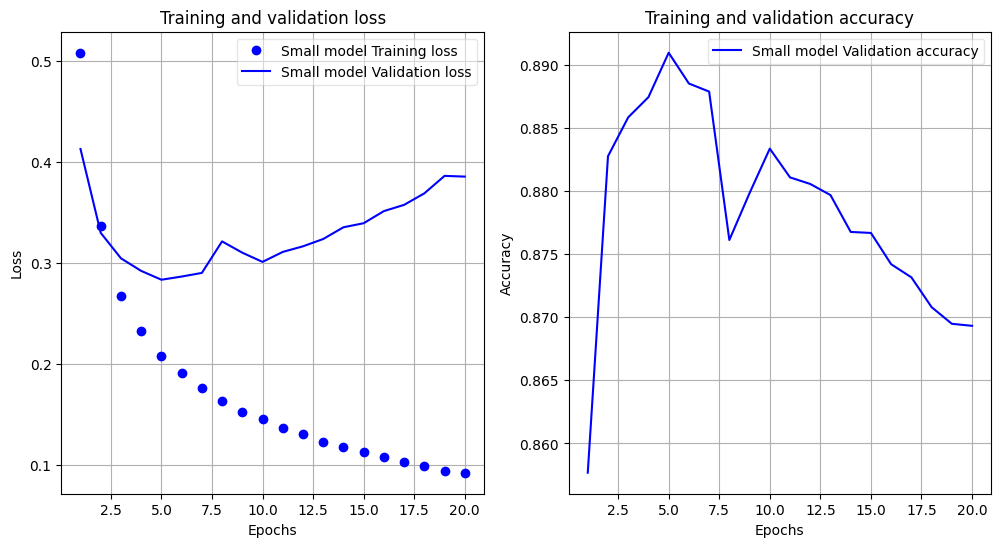

In [6]:
# Using the plotting function

plot_history(hist_a, color='blue', prefix="Small model")

### Part 4: Add Dropout Regularization
Objective: Experiment with dropout layers in the model.

**Instructions:**
1. Add another hidden layer with 8 units
1. Add dropout layers after each hidden layer with a dropout rate of 0.3.
1. Compile the model.
1. Train the model and observe the changes in accuracy.

Complete the code below:

In [7]:
drp_model = models.Sequential()
drp_model.add(layers.InputLayer(shape=(10000,)))
drp_model.add(layers.Dense(8, activation='relu'))
drp_model.add(layers.Dropout(0.3))
drp_model.add(layers.Dense(8, activation='relu'))
drp_model.add(layers.Dropout(0.3))
drp_model.add(layers.Dense(1, activation='sigmoid'))

drp_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])

drp_model.summary()

drp_history = drp_model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,089 (312.85 KB)

 Trainable params: 80,089 (312.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - acc: 0.6758 - loss: 0.6081 - val_acc: 0.8477 - val_loss: 0.4792
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - acc: 0.7938 - loss: 0.4758 - val_acc: 0.8734 - val_loss: 0.3791
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - acc: 0.8377 - loss: 0.4003 - val_acc: 0.8742 - val_loss: 0.3474
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.8631 - loss: 0.3501 - val_acc: 0.8888 - val_loss: 0.3092
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.8784 - loss: 0.3170 - val_acc: 0.8881 - val_loss: 0.2881
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.8913 - loss: 0.2879 - val_acc: 0.8870 - val_loss: 0.2908
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.9029 - loss: 0.2624 - val_acc: 0.8846 - val_loss: 0.2870
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9142 - loss: 0.2399 - val_acc: 0.8854 - val_loss: 0.2872
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - acc: 0.9

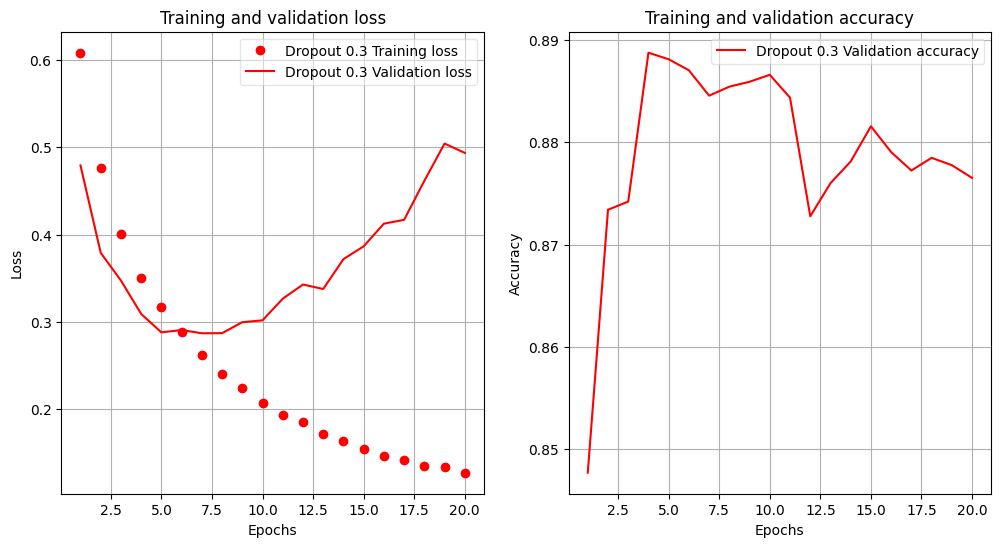

In [10]:
# Plot training history
plot_history(drp_history, color='red', prefix="Dropout 0.3")

### Part 5: Test Different Dropout Rates
Objective: Compare the model's performance with varying dropout rates.

**Instructions:**
1. Write a loop to create and train models with dropout rates of `[0, 0.2, 0.3, 0.4, 0.5]`.
2. For each model, record the history to plot it later


Complete the code below:

In [11]:
rates = [0, 0.2, 0.3, 0.4, 0.5]
hists = []

for rate in rates:
    print(f"Training model with dropout rate: {rate}")
    model = models.Sequential()
    model.add(layers.InputLayer(shape=(10000,)))
    model.add(layers.Dense(8, activation='relu'))
    model.add(layers.Dropout(rate))
    model.add(layers.Dense(8, activation='relu'))
    model.add(layers.Dropout(rate))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])

    hist = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
    hists.append(hist)

Training model with dropout rate: 0
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - acc: 0.7564 - loss: 0.5962 - val_acc: 0.8505 - val_loss: 0.5048
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - acc: 0.8722 - loss: 0.4254 - val_acc: 0.8710 - val_loss: 0.3919
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.8959 - loss: 0.3284 - val_acc: 0.8812 - val_loss: 0.3345
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9097 - loss: 0.2736 - val_acc: 0.8846 - val_loss: 0.3121
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9201 - loss: 0.2367 - val_acc: 0.8877 - val_loss: 0.2915
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9273 - loss: 0.2153 - val_acc: 0.8859 - val_loss: 0.2964
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9336 - loss: 0.1945 - val_acc: 0.8887 - val_loss: 0.2840
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9398 - loss: 0.1798 - val_acc: 0.8850 - val_loss: 0.2916
Epoch 9/20
49/49 ━━━━━━━━━━━

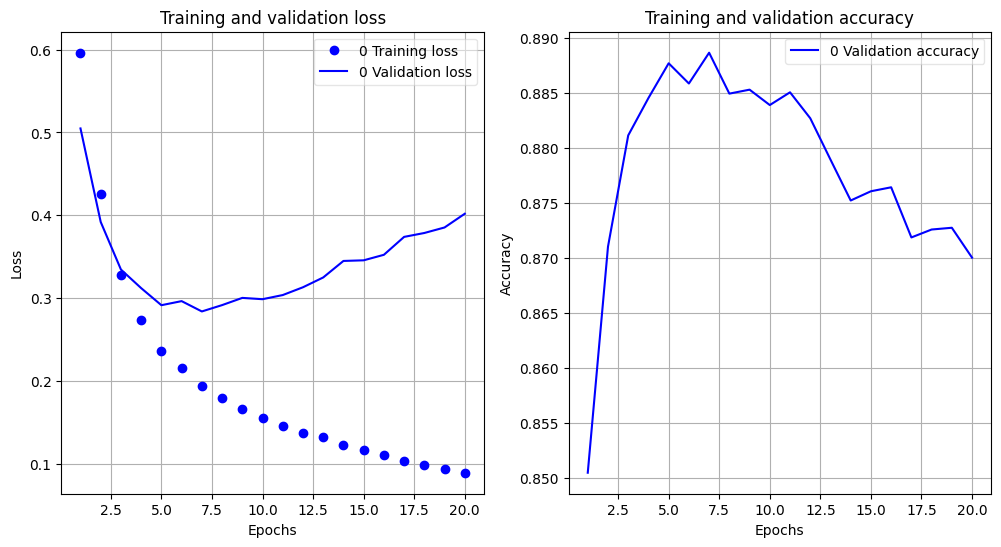

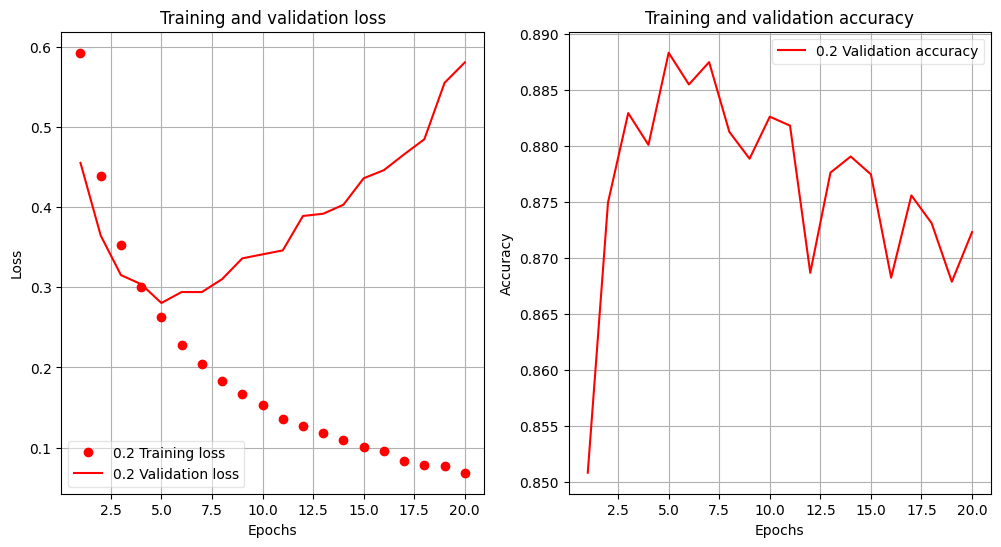

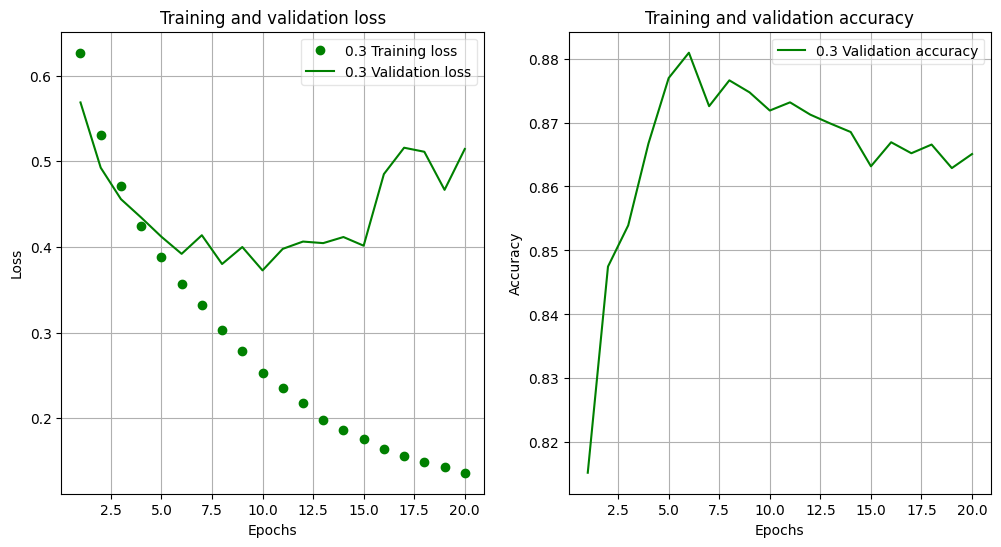

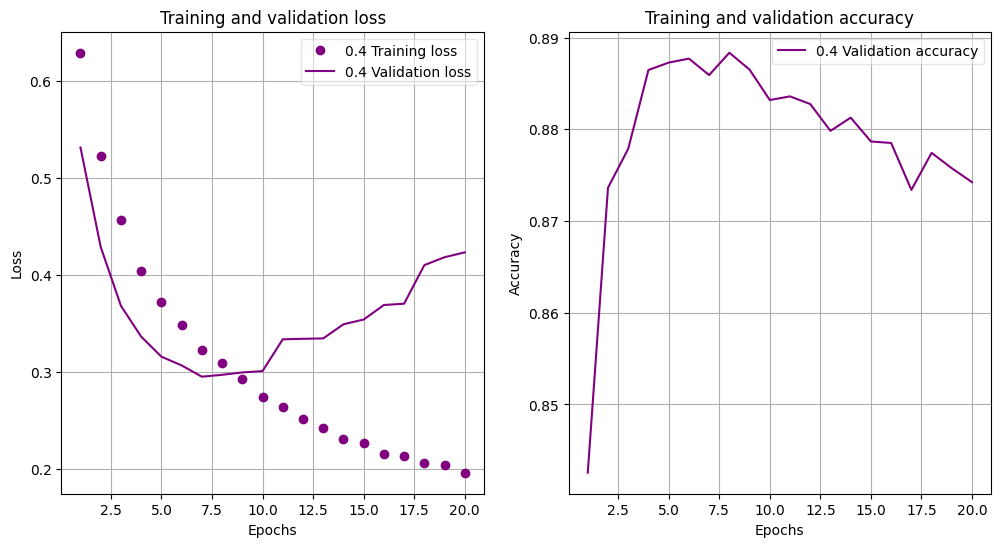

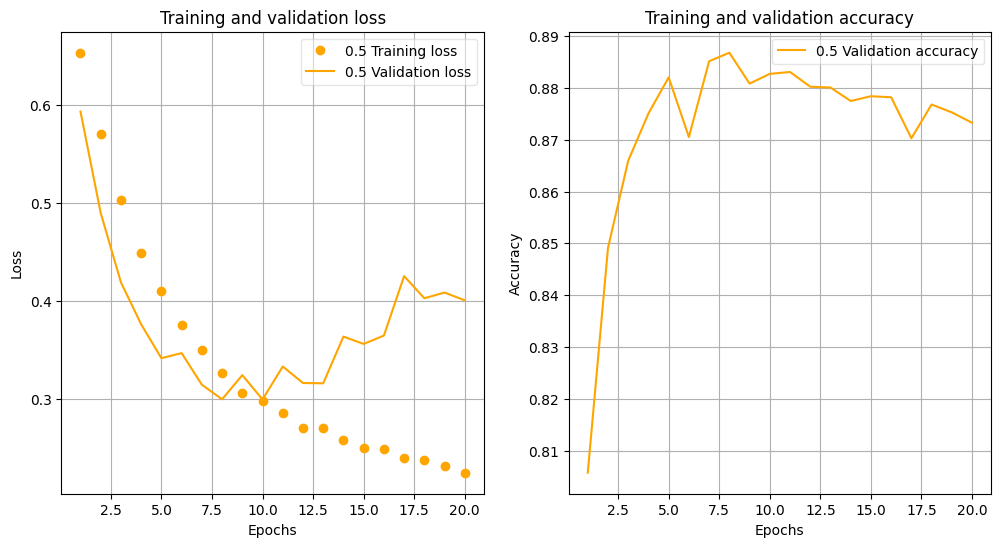

In [12]:
for i, hist in enumerate(hists):
    plot_history(hist, colors[i], prefix=str(rates[i]))

### Part 6: Experiment with dropout location
Objective: Compare the model's performance with dropout placed after different layers

**Instructions:**
Create 3 models with a single dropout "layer" placed:
1. Before the first dense layer only
2. After the first dense layer only
3. After the second dense layer only



Complete the code below:

In [13]:
hists_b = []
rate = 0.4

# Model 1: Dropout BEFORE the first dense layer
model1 = models.Sequential()
model1.add(layers.InputLayer(shape=(10000,)))
model1.add(layers.Dropout(rate))
model1.add(layers.Dense(8, activation='relu'))
model1.add(layers.Dense(8, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))
model1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
hist1 = model1.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
hists_b.append(hist1)

# Model 2: Dropout AFTER the first dense layer only
model2 = models.Sequential()
model2.add(layers.InputLayer(shape=(10000,)))
model2.add(layers.Dense(8, activation='relu'))
model2.add(layers.Dropout(rate))
model2.add(layers.Dense(8, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))
model2.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
hist2 = model2.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
hists_b.append(hist2)

# Model 3: Dropout AFTER the second dense layer only
model3 = models.Sequential()
model3.add(layers.InputLayer(shape=(10000,)))
model3.add(layers.Dense(8, activation='relu'))
model3.add(layers.Dense(8, activation='relu'))
model3.add(layers.Dropout(rate))
model3.add(layers.Dense(1, activation='sigmoid'))
model3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
hist3 = model3.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
hists_b.append(hist3)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - acc: 0.7494 - loss: 0.5499 - val_acc: 0.8574 - val_loss: 0.4339
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.8508 - loss: 0.3908 - val_acc: 0.8831 - val_loss: 0.3438
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.8714 - loss: 0.3358 - val_acc: 0.8880 - val_loss: 0.3135
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.8835 - loss: 0.3008 - val_acc: 0.8631 - val_loss: 0.3423
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.8859 - loss: 0.2898 - val_acc: 0.8918 - val_loss: 0.2915
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.8888 - loss: 0.2784 - val_acc: 0.8879 - val_loss: 0.2930
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.8944 - loss: 0.2698 - val_acc: 0.8846 - val_loss: 0.2970
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.8955 - loss: 0.2600 - val_acc: 0.8889 - val_loss: 0.2885
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.897

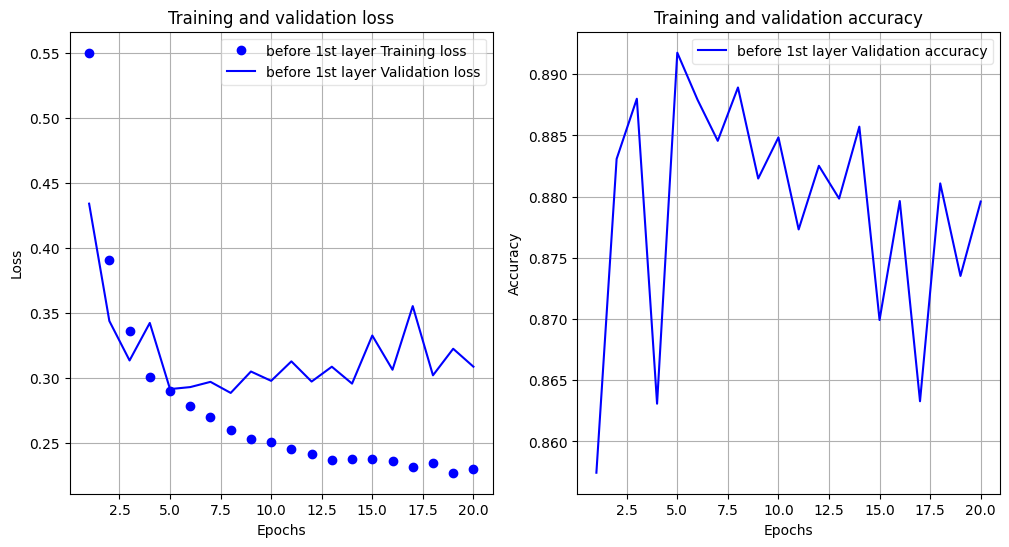

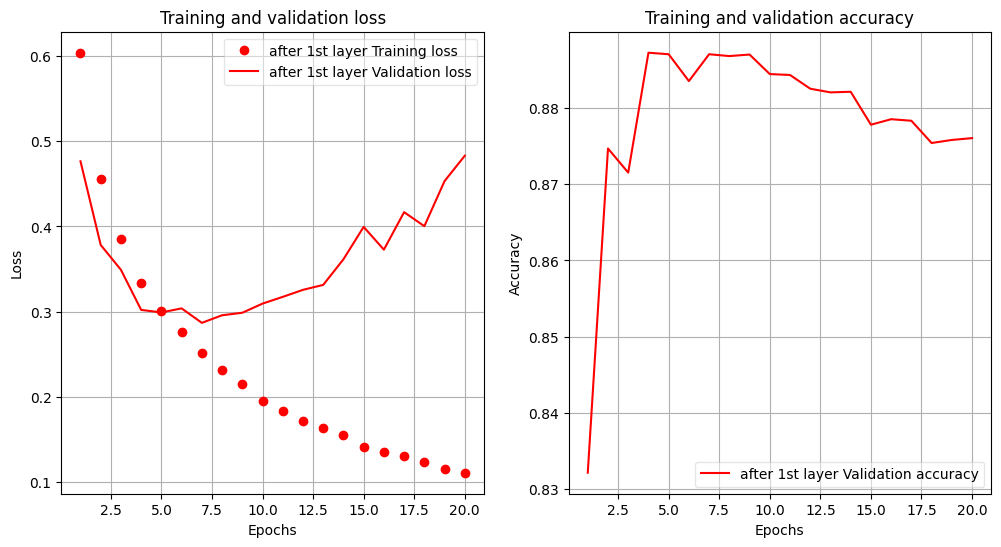

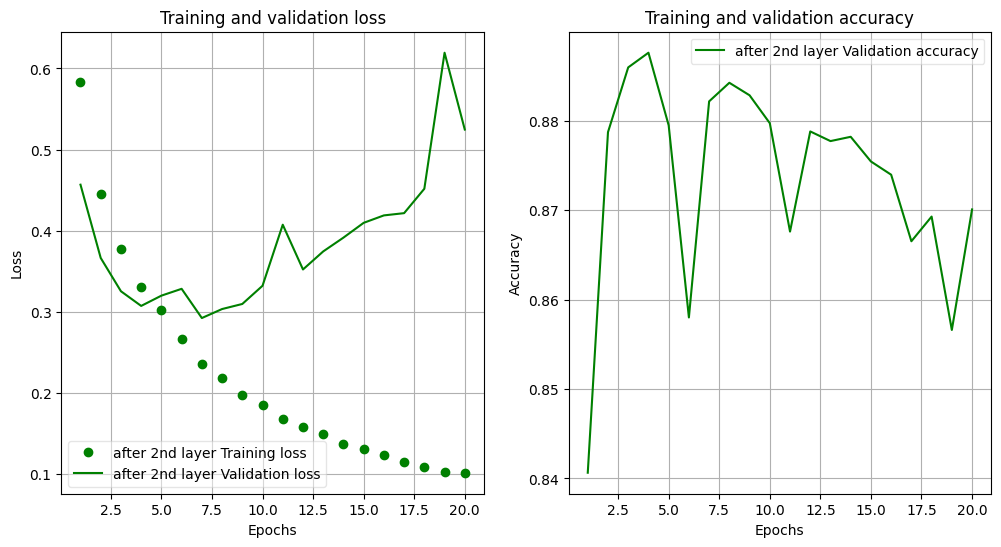

In [14]:
prefixes = ['before 1st layer', 'after 1st layer', 'after 2nd layer']
for i, hist in enumerate(hists_b):
    plot_history(hist, colors[i], prefix=prefixes[i])